# Машинное обучение, ФКН ВШЭ
## Практическое задание 4.

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Задание выполняется самостоятельно.

В финальной версии ноутбука, которая отправляется для сдачи задания, должны быть быть выполнены следующие условия:
* все ячейки выполнены для представленной в ноутбуке версии кода
* результаты выполнения ячеек отображены и согласованы с кодом
* при повторном запуске ячеек результаты должны воспроизводиться с точностью до случайности

### Формат сдачи
Для сдачи задания переименуйте получившийся файл \*.ipynb в соответствии со следующим форматом: *HW1_Username.ipynb*, где *Username* — Ваша фамилия и инициалы на латинице (например, *HW1_IvanovII.ipynb*). Далее отправьте этот файл на Smorodinov-1990@mail.ru.

## Кластеризация

Задача [кластеризации](https://en.wikipedia.org/wiki/Cluster_analysis) данных является одним из примеров задач обучения "без учителя". Она заключается в разбиении множества объектов на заданное число кластеров, при этом предполагается, что внутри одного кластера будут находиться похожие между собой объекты. Одним из примеров методов кластеризации является алгоритм [KMeans](https://en.wikipedia.org/wiki/K-means_clustering).

### Выбор числа кластеров

Для некоторых алгоритмов кластеризации число кластеров является гиперпараметром (например, в случае KMeans). Поэтому для выбора количества кластеров может быть использован следующий подход: при фиксированной метрике качества для разного числа кластеров обучают алгоритм и выбирают то значение гиперпараметра, начиная с которого качество "стабилизируется".

### Метрики качества

Оценивание качества построенной кластеризации — не всегда тривиальная задача, поскольку следует учитывать ряд фактов:
 - объекты одного класса должны быть более похожи друг на друга, чем на объекты других кластеров, относительно некоторой заданной метрики похожести;
 - метрика не должна учитывать истинные значения меток объектов, попавших в кластер (в случае, если истинные метки известны).

При выполнении задания для оценки качества получившейся кластеризации воспользуемся следующими метриками:
 - [Homogeneity и Completeness](http://scikit-learn.org/stable/modules/clustering.html#homogeneity-completeness-and-v-measure) 
 - [Adjusted Rand index](http://scikit-learn.org/stable/modules/clustering.html#rand-index) 
 - [Silhouette Coefficient](http://scikit-learn.org/stable/modules/clustering.html#silhouette-coefficient)

Загрузите набор данных [digits](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html). Перед применением алгоритмов не забудьте перемешать изображения в случайном порядке.

In [2]:
from sklearn.datasets import load_digits
import numpy as np
from sklearn.utils import shuffle

X, y = load_digits(return_X_y=True)
X, y = shuffle(X, y, random_state=42)

# import matplotlib.pyplot as plt
# plt.imshow(X[0].reshape(8, 8), cmap='gray')
# plt.title(f'Label: {y[0]}')
# plt.show()

**1. (1 балл)** Кластеризуйте изображения при помощи алгоритма [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), подобрав число кластеров для любой фиксированной метрики из указанных выше. Рассмотрите различные способы выбора начального приближения (параметр *init*). Оцените качество получившейся кластеризации, используя все описанные выше метрики. Визуализируйте изображения, соответствующие центроидам лучшей кластеризации.

Init: k-means++
Homogeneity: 0.740
Completeness: 0.748
Adjusted Rand Index: 0.668
Silhouette Coefficient: 0.182
------------------------------
Init: random
Homogeneity: 0.741
Completeness: 0.750
Adjusted Rand Index: 0.669
Silhouette Coefficient: 0.183
------------------------------
Лучшая инициализация: random


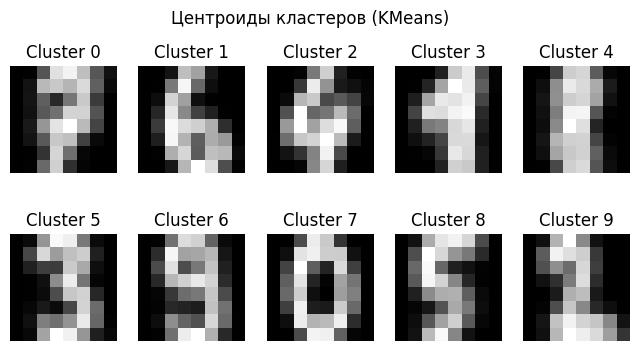

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import homogeneity_score, completeness_score, adjusted_rand_score, silhouette_score
import matplotlib.pyplot as plt

results = []
for init in ['k-means++', 'random']:
    kmeans = KMeans(n_clusters=10, init=init, n_init=20, random_state=42)
    clusters = kmeans.fit_predict(X)
    hom = homogeneity_score(y, clusters)
    comp = completeness_score(y, clusters)
    ari = adjusted_rand_score(y, clusters)
    sil = silhouette_score(X, clusters)
    results.append({
        'init': init,
        'homogeneity': hom,
        'completeness': comp,
        'ARI': ari,
        'silhouette': sil,
        'kmeans': kmeans
    })
    print(f"Init: {init}")
    print(f"Homogeneity: {hom:.3f}")
    print(f"Completeness: {comp:.3f}")
    print(f"Adjusted Rand Index: {ari:.3f}")
    print(f"Silhouette Coefficient: {sil:.3f}")
    print('-'*30)

best = max(results, key=lambda d: d['silhouette'])
print(f"Лучшая инициализация: {best['init']}")

fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(best['kmeans'].cluster_centers_[i].reshape(8, 8), cmap='gray')
    ax.set_title(f'Cluster {i}')
    ax.axis('off')
plt.suptitle('Центроиды кластеров (KMeans)')
plt.show()

Не всегда бывает удобно работать с полной матрицей объект-признак — например, для визуализации подходят лишь выборки размерности не больше трёх. На лекциях был рассмотрен метод уменьшения размерности *PCA*. В документации sklearn есть [сравнение](http://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html#example-manifold-plot-lle-digits-py) различных способов понижения размерности для проекции на плоскость. На изображениях видно, что некоторые преобразования дают неплохую визуализацию, где одинаковые цифры расположены близко друг к другу. Посмотрим, поможет ли это на практике.
 
**2. (1 балл)** Примените преобразования [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) и [t-SNE](http://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) (для числа компонент 2 и 10), проведите кластеризацию в новых признаковых пространствах и сравните результаты с предыдущими. Нашелся ли метод кластеризации, превосходящий другие по всем метрикам? Являются ли все три метрики согласованными? Можете ли вы объяснить, почему так произошло?

In [4]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def cluster_and_evaluate(X_proj, y, n_clusters=10, init='k-means++', name=''):
    kmeans = KMeans(n_clusters=n_clusters, init=init, n_init=20, random_state=42)
    clusters = kmeans.fit_predict(X_proj)
    hom = homogeneity_score(y, clusters)
    comp = completeness_score(y, clusters)
    ari = adjusted_rand_score(y, clusters)
    sil = silhouette_score(X_proj, clusters)
    print(f"{name} (init={init}):")
    print(f"  Homogeneity: {hom:.3f}")
    print(f"  Completeness: {comp:.3f}")
    print(f"  Adjusted Rand Index: {ari:.3f}")
    print(f"  Silhouette Coefficient: {sil:.3f}")
    print('-'*30)
    return dict(hom=hom, comp=comp, ari=ari, sil=sil)

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X)
cluster_and_evaluate(X_pca2, y, name='PCA (2 компоненты)')

pca10 = PCA(n_components=10, random_state=42)
X_pca10 = pca10.fit_transform(X)
cluster_and_evaluate(X_pca10, y, name='PCA (10 компонент)')

X_tsne2 = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto').fit_transform(X)
cluster_and_evaluate(X_tsne2, y, name='t-SNE (2 компоненты)')

X_tsne10 = TSNE(n_components=10, random_state=42, init='pca', learning_rate='auto', method='exact').fit_transform(X)
cluster_and_evaluate(X_tsne10, y, name='t-SNE (10 компонент)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y, cmap='tab10', s=10)
axes[0].set_title('PCA (2 компоненты)')
axes[1].scatter(X_tsne2[:, 0], X_tsne2[:, 1], c=y, cmap='tab10', s=10)
axes[1].set_title('t-SNE (2 компоненты)')
plt.suptitle('Визуализация данных после снижения размерности')
plt.show()

PCA (2 компоненты) (init=k-means++):
  Homogeneity: 0.526
  Completeness: 0.530
  Adjusted Rand Index: 0.393
  Silhouette Coefficient: 0.394
------------------------------
PCA (10 компонент) (init=k-means++):
  Homogeneity: 0.723
  Completeness: 0.731
  Adjusted Rand Index: 0.652
  Silhouette Coefficient: 0.264
------------------------------
t-SNE (2 компоненты) (init=k-means++):
  Homogeneity: 0.911
  Completeness: 0.912
  Adjusted Rand Index: 0.888
  Silhouette Coefficient: 0.641
------------------------------


KeyboardInterrupt: 

**3. (1 балл)** Визуализируйте несколько изображений, которые во всех случаях были отнесены к неправильному кластеру (объект назовем ошибочно отнесенным, если он имеет иную метку класса, нежели большая часть объектов в кластере). Можете ли вы пояснить, почему так произошло?

## Разделение изображения на семантические компоненты

![RedPanda](http://imgur.com/6Aa52Lm.png)

Алгоритмы кластеризации могут применяться в самых разных целях. Например, в анализе изображений есть задача разделения изображения на семантические компоненты, которую можно решать в том числе с помощью алгоритмов кластеризации. 

Загрузите [изображения](https://disk.yandex.ru/d/Nsl0cWOsc9PO-g).

**4. (1 балл)** Для каждого изображения, используя кластеризацию KMeans, выделите компоненты, охарактеризовав каждый пиксель вектором признаков $\psi_i = [\lambda x_i, \lambda y_i, r_i, g_i, b_i]$, где 
$x_i$ и $y_i$ — координаты пикселя, $r_i, g_i, b_i$ — его цвет, $\lambda$ — параметр, выражающий важность пространственной связности перед цветовой похожестью.

**5. (1 балл)** Попробуйте выделить сегменты при помощи [спектральной кластеризации](http://scikit-learn.org/stable/modules/clustering.html#spectral-clustering). Обратите внимание на [пример в sklearn](http://scikit-learn.org/0.16/auto_examples/cluster/plot_lena_segmentation.html). Для ускорения работы алгоритма рекомендуется привести изображение к серому цвету. При необходимости можно сжать изображения в 2 раза.

**6. (1 балл)** Визуализируйте результаты сегментации (аналогично рисунку выше) для обоих методов. [Пример кода для визуализации](http://scikit-learn.org/0.16/auto_examples/cluster/plot_lena_segmentation.html).

**7. (1 балл)** Поэкспериментируйте с параметрами алгоритмов и параметром $\lambda$ в признаках. Сравните два подхода и сегментации, к которым они приводят.
Для всех ли изображений в результате сегментации хорошо видны контуры объектов?

Измерять качество сегментации в этом пункте не нужно, в результате ожидаются только картинки и выводы.

### Рекомендации к выполнению
Для работы с изображениями удобно использовать библиотеку [Scikit-Image](http://scikit-image.org). 
Установите [PIL](http://www.pythonware.com/products/pil/) для возможности чтения формата JPG.

Пример чтения изображения в матрицу [картинки](https://images.wallpapersden.com/image/download/4k-planet-pixel-art_bGprbGqUmZqaraWkpJRqZmetamZn.jpg):

    import matplotlib.pyplot as plt
    from skimage.io import imread

    I = imread("wallpapersden.com_k-planet-pixel-art_512x512.jpg") 

    plt.figure(figsize=(15, 5))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(I[:,:,i])

## Word2vec

**8. (3 балла)**
1. [Скачайте данные](https://www.kaggle.com/c/word2vec-nlp-tutorial/data). Если не получается, можно скачать и работать с [этими данными](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews).
2. [Установите необходимые библиотеки](https://www.kaggle.com/c/word2vec-nlp-tutorial/details/setting-up-your-system)
3. Внимательно изучите тьториалы, доступные в рамках контеста [Part 1](https://www.kaggle.com/c/word2vec-nlp-tutorial/details/part-1-for-beginners-bag-of-words) – [Part 4](https://www.kaggle.com/c/word2vec-nlp-tutorial/details/part-4-comparing-deep-and-non-deep-learning-methods). Эти статьи очень полезны для понимания принципов анализа текстовых данных в питоне.
4. Согласно тьюториалам подготовить данные и обучить модель word2vec. Полезно засечь время обучения модели.
5. Протестировать модель на датасете, подготовленном Google, с задачами вида: *London → England*, значит, *Berlin → Germany*. Пример вызова нужной функции и описание датасета есть [тьюториале по word2vec](https://rare-technologies.com/word2vec-tutorial/). Сам датасет можно скачать по [ссылке](https://www.dropbox.com/s/prb8n5b5na5qo07/questions-words.txt?dl=0). С чем может быть связано большое число неверных ответов?
6. Привести по 5-10 примеров для задачи поиска лишнего слова *(model.doesnt_match)* и для задачи поиска семантически близких слов *(model.most_similar)*. Проинтерпретировать полученные результаты. Все ли примеры соответствуют здравому смыслу? По каким принципам группируются близкие слова в выбранных вами примерах?